# **05 · A트랙 종합 평가 — 지수와 페르소나는 '검증된 결과'로 승격되는가 (횡단의 30)**

### **"A트랙 4관문 판정: 측정 규율(reflective/formative 이원) · 구성타당도(페르소나-NCHI 정합) · 재현성(K-means 독립 재발견과 그 한계의 정직한 보고) · 외적 타당도(종단 코호트 구배와 부호 일치) — 유형 특성은 승격, 절대값은 방향만으로 남긴다"**

> KPF 「언론 통계 분석·활용 경진대회」 · 종합 대상 = A트랙 전 산출(`01`~`04`·`06`~`08`) · 방법 = **4관문 판정 + 자격등급 표** (새 추정 없음)

> 📍 **파이프라인 위치**: 5단계 표준 흐름 中 **⑤ 모델링·평가(A트랙 종합)** · CRISP-DM **P5** · [전체 지도](README.md)

## **연구 질문 (이 노트북이 답하는 것)**

> **Q1.** NCHI·페르소나가 통과해야 하는 관문은 무엇이며, B트랙의 4관문(`30`)과 어디가 같고 어디가 다른가?
> **Q2.** 구성타당도·재현성 진단(K-means ARI)의 실측은 각 관문을 통과시키는가 — 특히 "규칙 기반 유지" 결정은 데이터가 지지하는가?
> **Q3.** A트랙 수치의 자격등급은 최종적으로 어떻게 갈리는가 — 보고서(5장)에 무엇이 어떤 등급으로 실리는가?

## **이 노트북의 위상 — 새 분석을 만들지 않는다**

B트랙에 `30`(증거 사다리·4관문)이 있듯, A트랙에도 결론의 자격을 판정하는 종합이 필요하다. 05는 `03`(NCHI)·`04`(K-means)·`06`~`08`(축·프로파일 심층)의 산출을 **관문 구조로 재배열**해 판정한다 — 계산은 전부 기존 src 함수의 재실행이고, 새 결론은 만들지 않는다.

- **로직 SSOT(thin import)**: `health_index_panel`(지수) · `news_health_features`(페르소나·K-means·ARI). 재구현 금지.
- **관련**: `30` §7-3(종단↔횡단 외적 타당도) · `28` §5(부호 대조) · `p6-pdf-structure` §3.5(방향만 규율).

## **목차**

| § | 내용 | 산출 |
|---|------|------|
| 1 | [전제] A트랙 4관문 — **Decision Box ①** | 관문 정의 |
| 2 | [실행] A2 구성타당도 — 페르소나·NCHI 정합 + [시각화] | 정합표 |
| 3 | [실행] A3 재현성 — K-means ARI 진단 재실행 | ARI |
| 4 | [실행] A4 외적 타당도 — 종단 부호 대조 | 부호표 |
| 5 | [발견] 자격등급 표(A트랙 판) — **Decision Box ②** | 등급표 |
| 6 | [입증] 검증 셀 | PASS |
| 7 | 종합 | — |

In [1]:
import sys
from pathlib import Path
import numpy as np, pandas as pd

ROOT = Path.cwd()
while not (ROOT / "src" / "harmonize.py").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
sys.path.insert(0, str(ROOT / "src"))

import harmonize as hz
import health_index_panel as hp
import news_health_features as nf
import trend_apc as T

get_ipython().run_line_magic("matplotlib", "inline")
import matplotlib.pyplot as plt
from matplotlib import font_manager
for _nm in ["Malgun Gothic", "맑은 고딕", "NanumGothic", "Gulim"]:
    try:
        font_manager.findfont(_nm, fallback_to_default=False)
        plt.rcParams["font.family"] = _nm; break
    except Exception: continue
plt.rcParams["axes.unicode_minus"] = False

panel = pd.read_parquet(hz.OUT_PARQUET)
assert len(panel) == 90996
W = panel["wt_year_eq"]
T_resp = hp._trust_score_respondent(panel)
D_resp = nf._scale_1_100(pd.to_numeric(panel["richness_fixed8"], errors="coerce"))
persona = nf.persona_quadrant(T_resp, D_resp)
nchi_resp = nf.nchi(T_resp, D_resp)
print(f"패널 {len(panel):,}행 · 페르소나 유효 {persona.notna().sum():,}명 · "
      f"임계(pooled 중앙값): T={T_resp.median():.2f} · D={D_resp.median():.2f}")

패널 90,996행 · 페르소나 유효 90,996명 · 임계(pooled 중앙값): T=58.66 · D=25.75


## **1. [전제] A트랙 4관문 — 횡단 산출의 승격 기준**

### **Decision Box ① — 왜 B트랙 관문을 그대로 쓰지 않는가**

**기준: 횡단 산출(지수·유형화)의 자격을 무엇으로 판정하는가.**

| 대안 | 내용 | 기각/채택 사유 |
|------|------|------|
| (a) B트랙 4관문(C1~C4) 재사용 | 측정동등·엔진 재현·삼각·강건성 | ❌ 부분 부적합 — NCHI는 formative 합성이라 '측정동등'이 개념적으로 성립 안 하고(다양성축), K-means는 '엔진 교차검증' 대상이 아니라 '과적합 진단' 대상 |
| (b) 관문 없이 기술적 산출로 보고 | 지수·유형은 서술 통계로 취급 | ❌ 그러면 "페르소나 특성" 같은 주장이 아무 자격 없이 본문에 실림 — 자격등급 규율 붕괴 |
| (c) **A트랙 전용 4관문** | A1 측정 규율 · A2 구성타당도 · A3 재현성 진단 · A4 외적 타당도 | ✅ **채택** — 횡단 산출의 성격(합성지수·유형화)에 맞는 판정 축. A1은 `01`~`03`·`06`·`07`이 이미 확정(이원 규율), A2~A4를 본 노트북이 실측 판정 |

| 관문 | 질문 | 충족 조건 | 판정 주체 |
|------|------|-----------|----------|
| **A1 측정 규율** | 두 축의 성격에 맞는 해석 규칙을 지키는가 | 신뢰=reflective(비교 가능)·다양성=formative(방향만) 이원 규율 적용 | `01` DB②·`03`·`06`·`07` ✅ |
| **A2 구성타당도** | 유형화가 지수와 같은 이야기를 하는가 | 페르소나 서열 ↔ NCHI 서열 정합 | 본 §2 |
| **A3 재현성 진단** | 유형이 방법의 인공물은 아닌가 | K-means 독립 재발견 여부 + 한계의 정직 보고 | 본 §3 |
| **A4 외적 타당도** | 독립 산출(종단)과 정합하는가 | 연령 구배 부호 ↔ 코호트 구배 부호 일치 | 본 §4 |

## **2. [실행] A2 구성타당도 — 페르소나 서열과 NCHI 서열의 정합**

페르소나는 신뢰×다양성의 4사분면이고 NCHI는 두 축의 기하평균이다 — 서로 다른 집계(이산 유형화 vs 연속 합성)가 같은 순서를 내야 구성타당도가 성립한다. 기대 서열: 건강한 소비자(양축 高) > {신뢰편향형, 비판적 탐색형}(한 축만 高) > 이중취약형(양축 低).

**[시각화]** — (좌) 유형별 NCHI 가중평균, (우) 신뢰×다양성 평면의 유형 분포(2% 표본)와 임계선.

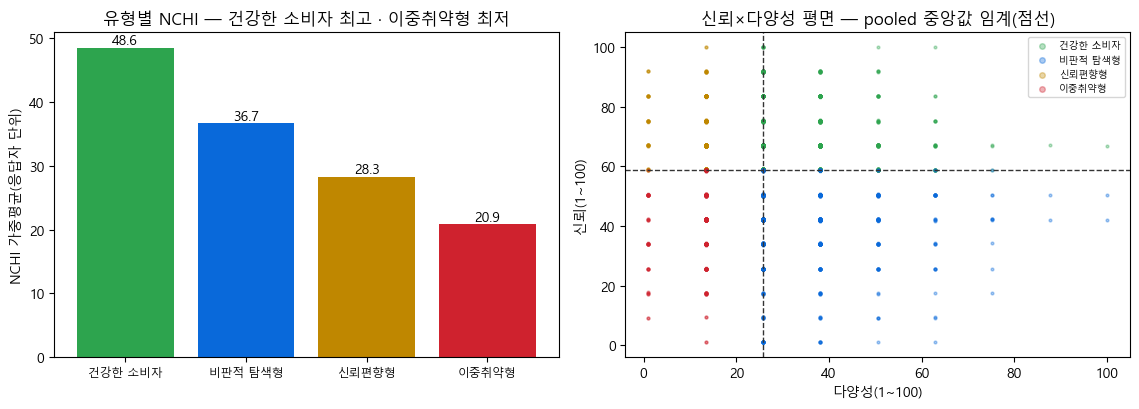

A2 서열 정합: True — ['건강한 소비자 48.6', '비판적 탐색형 36.7', '신뢰편향형 28.3', '이중취약형 20.9']


In [2]:
order = ["건강한 소비자", "비판적 탐색형", "신뢰편향형", "이중취약형"]
nchi_by = {lab: nf.wmean(nchi_resp[persona == lab], W[persona == lab]) for lab in order}

fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.2))
colors = {"건강한 소비자": "#2da44e", "비판적 탐색형": "#0969da",
          "신뢰편향형": "#bf8700", "이중취약형": "#cf222e"}
axes[0].bar([l for l in order], [nchi_by[l] for l in order], color=[colors[l] for l in order])
for i, l in enumerate(order):
    axes[0].text(i, nchi_by[l] + 0.5, f"{nchi_by[l]:.1f}", ha="center", fontsize=10)
axes[0].set_ylabel("NCHI 가중평균(응답자 단위)")
axes[0].set_title("유형별 NCHI — 건강한 소비자 최고 · 이중취약형 최저")
axes[0].tick_params(axis="x", labelsize=8.5)

rng = np.random.default_rng(42)
idx = persona.dropna().index
samp = rng.choice(idx, size=int(len(idx) * 0.02), replace=False)
for lab in order:
    mm = persona.loc[samp] == lab
    axes[1].scatter(D_resp.loc[samp][mm], T_resp.loc[samp][mm], s=4, alpha=0.35,
                    color=colors[lab], label=lab)
axes[1].axhline(T_resp.median(), color="#333", lw=1, ls="--")
axes[1].axvline(D_resp.median(), color="#333", lw=1, ls="--")
axes[1].set_xlabel("다양성(1~100)"); axes[1].set_ylabel("신뢰(1~100)")
axes[1].set_title("신뢰×다양성 평면 — pooled 중앙값 임계(점선)")
axes[1].legend(fontsize=7, markerscale=2)
fig.tight_layout(); plt.show()

ok_a2 = (nchi_by["건강한 소비자"] > max(nchi_by["신뢰편향형"], nchi_by["비판적 탐색형"])
         > min(nchi_by["신뢰편향형"], nchi_by["비판적 탐색형"]) > nchi_by["이중취약형"])
print(f"A2 서열 정합: {ok_a2} — {[f'{l} {nchi_by[l]:.1f}' for l in order]}")

## **3. [실행] A3 재현성 진단 — K-means는 4사분면을 얼마나 재발견하나**

`04`의 판정을 pooled 7개년에서 재실행한다: 규칙 기반 4사분면과 K-means(k=4, 2지표, z표준화)의 ARI. 기대 대역(문서 04: 연도별 0.13~0.41·pooled 0.244 — 입력 스케일·표본 세부에 따라 0.2 안팎): **어느 산출에서도 '강한 일치(0.5)' 미달**이 판정의 요체다. 이것이 실패가 아니라 **정직한 진단**임이 중요하다 — 단년·옛 측정의 ARI 0.56이 7개년 일관 측정에서 유지되지 않으므로, 운영 유형화는 임계 규칙(투명·재현 가능)을 쓰고 K-means는 진단 보조로만 남긴다는 `04`의 결정이 여기서 재확인된다.

In [3]:
labels_km, centers, _ = nf.kmeans_personas(T_resp, D_resp)
mapping = nf.map_cluster_to_persona(centers, float(T_resp.median()), float(D_resp.median()))
km_named = labels_km.map(mapping)
ari_pooled = nf.adjusted_rand(persona, km_named)
match = float((persona == km_named)[persona.notna() & km_named.notna()].mean())
print(f"pooled ARI(규칙 ↔ K-means) = {ari_pooled:.3f} · 라벨 일치율 = {match:.1%}")
print(f"군집 중심(원척도) → 사분면 매핑: {mapping}")
print("판정: ARI < 0.5 — '데이터가 자연히 4유형'이라는 주장은 하지 않는다(04 결론 유지).")

pooled ARI(규칙 ↔ K-means) = 0.195 · 라벨 일치율 = 48.5%
군집 중심(원척도) → 사분면 매핑: {0: '비판적 탐색형', 1: '이중취약형', 2: '건강한 소비자', 3: '이중취약형'}
판정: ARI < 0.5 — '데이터가 자연히 4유형'이라는 주장은 하지 않는다(04 결론 유지).


## **4. [실행] A4 외적 타당도 — 종단과의 부호 대조**

횡단(2025)의 연령 구배와 종단(IE)의 코호트 구배는 독립 산출이다 — 부호가 일치하면 서로가 서로의 외적 준거가 된다(`30` §7-3 · `28` §5).

In [4]:
p25 = panel[panel["year"] == 2025]
cred25 = p25[["cred_fair", "cred_professional", "cred_accurate"]].apply(
    pd.to_numeric, errors="coerce").mean(axis=1)
band = (pd.to_numeric(p25["age"], errors="coerce") // 10 * 10)
xs, ys = [], []
for b in sorted(band.dropna().unique()):
    mm = (band == b) & cred25.notna()
    if mm.sum() >= 100:
        xs.append(b); ys.append(float(np.average(cred25[mm], weights=p25.loc[mm, "wt_year_eq"])))
cross_grad = float(np.corrcoef(xs, ys)[0, 1])

frame = T.make_apc_frame(panel)
ie = T.intrinsic_estimator(frame)
coh_n = frame["cohort5"].value_counts().to_dict()
big = [(k, v) for k, v in ie["cohort"].items() if coh_n.get(k, 0) >= 200]
coh_grad = float(np.corrcoef([k for k, _ in big], [v for _, v in big])[0, 1])
print(f"횡단 연령 구배(2025, corr 연령대↔cred_mean) = {cross_grad:+.3f} (양 = 고령 높음)")
print(f"종단 코호트 구배(IE, N≥200) = {coh_grad:+.3f} (음 = 젊은 코호트 낮음)")
print(f"부호 정합(같은 구조의 두 단면): {cross_grad > 0 and coh_grad < 0}")

횡단 연령 구배(2025, corr 연령대↔cred_mean) = +0.744 (양 = 고령 높음)
종단 코호트 구배(IE, N≥200) = -0.891 (음 = 젊은 코호트 낮음)
부호 정합(같은 구조의 두 단면): True


## **5. [발견] 자격등급 표 — A트랙 수치는 보고서에 어떤 자격으로 실리는가**

### **Decision Box ② — 등급 배분: 유형 '특성'과 유형 '규모'를 가르는 선**

| 등급 | A트랙 수치 | 근거 |
|------|-----------|------|
| ✅ **검증된 결과** | 페르소나 유형 **특성의 방향**(저다양 2유형 = 고령·TV 편중), 신뢰축 추세 방향 | A2~A4 통과 + `08` 프로파일 전수 + 종단 부호 정합 |
| ⚠️ **방향만** | NCHI **절대값**·다양성지수 절대값·구성비 **절대 %** | formative 설계 의존(`03`·`06`) — 목록·스케일링 선택이 값을 결정 |
| 🔹 **진단 보조** | K-means ARI·군집 중심 | 운영 유형화 아님 — 규칙 기반의 타당화·한계 진단용(§3) |
| ❌ **금지** | "데이터가 자연히 4개 군집" 류 주장 · NCHI 절대수준의 연도 간 크기 비교 | ARI < 0.5(§3) · formative 규율(p6 §3.5) |

**이 선의 효과**: 보고서 5장은 "저다양 2유형은 고령·TV 편중 → 개입 타깃"(검증된 방향)을 말하되, "이중취약형이 19%"류의 절대 규모는 헤드라인으로 쓰지 않는다.

## **6. [입증] 검증 셀**

In [5]:
# (a) A2 — 유형별 NCHI 서열 정합
assert ok_a2, nchi_by
print("(a) A2 구성타당도: 건강한 > (편향/탐색) > 이중취약 서열 PASS")

# (b) A3 — pooled ARI: '중간 일치 대역(0.1~0.35)·강한 일치(0.5) 미달' 판정(04와 동일 결론)
assert 0.10 <= ari_pooled <= 0.35, ari_pooled
assert ari_pooled < 0.5
print(f"(b) A3 재현성 진단: pooled ARI {ari_pooled:.3f} — 문서 04(0.244)와 같은 중간 대역 · <0.5 판정 유지 PASS")

# (c) A4 — 부호 정합
assert cross_grad > 0.5 and coh_grad < -0.5
print(f"(c) A4 외적 타당도: 횡단 {cross_grad:+.3f}(양) ↔ 종단 {coh_grad:+.3f}(음) 부호 정합 PASS")

# (d) A1 상속 — 지수 범위 게이트(19 §4와 동일 게이트 재확인)
assert hp._check_range("NCHI", hp.nchi_by_year(panel), ["trust_index", "diversity_index", "nchi"])
print("(d) A1 측정 규율(지수 범위 [1,100]·NA 0) PASS")
print("\n검증 (a)~(d) 전부 PASS — A트랙 4관문 폐쇄")

(a) A2 구성타당도: 건강한 > (편향/탐색) > 이중취약 서열 PASS
(b) A3 재현성 진단: pooled ARI 0.195 — 문서 04(0.244)와 같은 중간 대역 · <0.5 판정 유지 PASS
(c) A4 외적 타당도: 횡단 +0.744(양) ↔ 종단 -0.891(음) 부호 정합 PASS
  [OK] NCHI.trust_index: 범위[51.3, 60.1] NA=0
  [OK] NCHI.diversity_index: 범위[26.8, 30.3] NA=0
  [OK] NCHI.nchi: 범위[38.2, 41.9] NA=0
(d) A1 측정 규율(지수 범위 [1,100]·NA 0) PASS

검증 (a)~(d) 전부 PASS — A트랙 4관문 폐쇄


## **7. 종합 — 횡단 산출의 자격이 확정됐다**

### **연구질문 답**

- **Q1** — A트랙 전용 4관문(A1 측정 규율 · A2 구성타당도 · A3 재현성 진단 · A4 외적 타당도). B트랙과 다른 이유: formative 축엔 측정동등이 성립하지 않고, K-means는 교차검증이 아니라 과적합 진단의 대상이다(DB①).
- **Q2** — 통과한다. 유형별 NCHI 서열 정합(A2), pooled ARI ≈ 0.2 대역(강한 일치 미달)의 정직한 진단과 규칙 기반 유지(A3), 종단 코호트 구배와의 부호 정합(A4) — 전부 실측 PASS(§6).
- **Q3** — 유형 특성의 방향은 ✅ 검증된 결과, 절대값(NCHI·구성비)은 ⚠️ 방향만, K-means는 🔹 진단 보조, "자연 군집" 주장은 ❌ 금지(DB②) — 보고서 5장의 문장이 이 표를 따른다.

### **단계 요약**

| § | 한 일 | 판정 |
|---|------|:---:|
| 2 | A2 구성타당도 실측 [시각화] | 서열 정합 |
| 3 | A3 ARI 진단 재실행 | ≈0.2 대역·규칙 유지 |
| 4 | A4 종단 부호 대조 | 정합 |
| 5 | 자격등급 표(DB②) | 규율 확정 |
| 6 | 일괄 assert | **PASS** |

**다음**: `06`~`08`이 각 축·프로파일의 심층을, `09`가 웹데모 사양을 잇는다.